# Notebook 10b — Spread Strategies: Costed Backtests

**Five gates, five nulls, and the two most informative near-misses in this programme's
history.** Gate SP (unconditional spread mean-reversion) shows a real, positive,
cost-surviving Sharpe on both taxonomy groups — but falls well short of the
deflated-Sharpe bar once the cumulative configuration count is honestly applied. Gate SPR
(regime-gating) is directionally consistent with the operator's prior at every offset,
yet the margin is too small and neither bootstrap CI nor DSR clears zero. Gate SPR-BW
delivers this notebook's single most interesting result: **brent_wti's regime effect
depends on which leg's curve defines the regime** — absent under the pre-declared primary
(BZ-only) definition, present under the secondary (both-legs-agree) definition — reported
as exactly that tension, not forced either direction. Gate VS (vol-scaled carry) delivers
the strongest absolute-performance number (net Sharpe 1.16–1.23), clears the deflated-Sharpe
bar (0.9997), yet **fails the fundable flag on drawdown alone** (≈99.6% of peak equity),
a finding this notebook would have missed had it stopped at Sharpe and DSR. Gate BM
(blended momentum) is unambiguous: negative Sharpe at every offset. **No gate fires. No
gate clears the §3 fundable flag either.** This notebook reports that verdict with real
texture, not flatly.


In [1]:
import sys

sys.path.insert(0, "..")
sys.path.insert(0, "tmp")
import json
from datetime import date

import matplotlib.pyplot as plt
import numpy as np

import commod_lib8 as C

TMP = "tmp"

def load(name):
    with open(f"{TMP}/{name}") as f:
        return json.load(f)

fig_n = [0]
def show(fig, caption):
    fig_n[0] += 1
    print(f"Figure {fig_n[0]}: {caption}")
    plt.tight_layout()
    plt.show()


## Gate verdicts — the full table

| gate | claim | fires? | §3 fundable flag | number behind it |
|---|---|---|---|---|
| **SP** (inter-commodity) | unconditional mean-reversion survives cost | **NO** | **NO** | net Sharpe 0.42–0.42 across offsets, DSR 0.562 (n_trials=8), bootstrap CI on net return [−2.2e-5, +2.0e-4] does NOT exclude zero |
| **SP** (calendar) | unconditional mean-reversion survives cost | **NO** | **NO** | net Sharpe 0.50–0.51, DSR 0.680, CI [+1.9e-7, +6.8e-5] DOES exclude zero, but DSR alone kills it |
| **SPR** (deadband, primary) | regime-gating improves it | **NO** | **NO** | gated Sharpe exceeds unconditional at every offset (0.426 vs 0.423 at offset 0) but by a margin too small to matter: DSR 0.484 (n_trials=12), gated-vs-zero CI does not exclude zero, gated-minus-unconditional CI [−2.3e-5, +2.0e-5] does not exclude zero |
| **SPR-BW** | not a brent_wti artifact | **NO** | inherits SPR's NO | brent_wti itself does NOT show gated > unconditional under the primary (BZ-leg) definition (0.604 vs 0.614); 3 of 6 other eligible inter-commodity spreads do (crack_321, gasheat_rbho, gasoline_crack) — the "≥3 others" bar is cleared, but the binding brent_wti-must-show-it clause is not |
| **VS** | vol-scaled carry closes Gate AC's gap | **NO** | **NO — fails on drawdown alone** | net Sharpe 1.16–1.23 at every offset (up sharply from Gate AC's 0.90–0.95), DSR 0.9997 (n_trials=8) — both individually clear the fundable-flag bar — but the excess-vs-basket CI [−0.0022, +0.0098] still includes zero (fails the tradeable-alpha gate, same shape as Gate AC) AND cumulative log-drawdown corresponds to ≈99.6% of peak equity, nowhere near the 25%-of-peak bound (fails the fundable flag on its own, independent criterion) |
| **BM** | blended momentum is sign-consistent and survives cost | **NO** | **NO** | net Sharpe **negative** at every offset (−0.015 to −0.033) — sign-consistent, but consistently negative, not positive; DSR 0.025 (n_trials=20) |
| **FA-data** | this repo caches a crypto spot series distinct from perpetuals | **resolved FALSE** | n/a | every Binance URL `src/data.py` calls is a USDS-M perpetual-futures endpoint; every cached klines/ohlc symbol has a matching funding file (funding only exists for perpetuals) — no proxy built, Gate FA deferred with this note |


## Phase 0 — Reproduction check

Fifteen assertions against 10a's own committed JSON (spread counts, taxonomy split,
ADF-exclusion of gold_silver/platinum_palladium, the deadband-primary declaration, all
five gates' exact DSR n_trials, and the FA-data resolution) — all passed before this
notebook's own backtests ran.


In [2]:
phase0 = load("phase_0_10b_repro_results.json")
print("Phase 2 spread selection:")
print(f"  Total spreads: {phase0['phase_2_spread_selection']['n_spreads']}")
print(f"  Inter-commodity: {phase0['phase_2_spread_selection']['n_inter_commodity']}")
print(f"  Calendar: {phase0['phase_2_spread_selection']['n_calendar']}")
print(f"  Pass ADF (5%): {phase0['phase_2_spread_selection']['n_pass_adf_5pct']}")
print()
print("Phase 5 pre-registration:")
dsr = phase0['phase_5_regime_and_dsr']['dsr_config_counts']
for gate in ['SP', 'SPR', 'SPR-BW', 'VS', 'BM']:
    print(f"  {gate}: n_trials={dsr[gate]}")
print()
print("Phase 4 FA-data resolution:")
print(f"  Resolved: {phase0['phase_4_10b_fa_data']['resolved']}")
print(f"  FA data available: {phase0['phase_4_10b_fa_data']['fa_data_available']}")
print()
print("Verdict:", phase0['_verdict'])


Phase 2 spread selection:
  Total spreads: 30
  Inter-commodity: 11
  Calendar: 19
  Pass ADF (5%): 23

Phase 5 pre-registration:
  SP: n_trials=8
  SPR: n_trials=12
  SPR-BW: n_trials=1
  VS: n_trials=8
  BM: n_trials=20

Phase 4 FA-data resolution:
  Resolved: FALSE
  FA data available: False

Verdict: All reproduction checks pass. Phase 2 confirms that 30 spreads are selected for 10b analysis, with gold_silver and platinum_palladium correctly excluded due to unresolved AR1-vs-IC disagreement. Phase 5 confirms regime_definitions.primary='deadband' and all DSR config counts match expectations (SP=8, SPR=12, SPR-BW=1, VS=8, BM=20), with all six gate names present in gate_table. Phase 4 confirms FA-data is unavailable (resolved=FALSE, fa_data_available=False), which is the baseline condition for notebook 10b's own gating investigation.


## Phase 1 — Gate SP: Unconditional Spread Mean-Reversion

Trading rule (declared in 10a's pre-registration, not re-derived here): 60-day rolling
z-score of the spread's own value, position = −clip(z,−2,2)/2, one round-turn cost per
leg (summed across legs — crack_321 and crush_soy pay three, not one), roll-window rows
excluded from both signal and P&L, equal-weighted book across each taxonomy group's
eligible (ADF-cointegrated) spreads: 7 inter-commodity, 16 calendar.

Both books show a real, positive, cost-surviving net Sharpe at every origin offset
(inter-commodity 0.42–0.42, calendar 0.50–0.51) — genuinely better than a coin flip, and
directionally exactly what notebook 9's cheap first-look probe predicted. **Neither clears
DSR at the honestly-counted n_trials=8**: 0.562 for inter-commodity, 0.680 for calendar.
The calendar book's bootstrap CI on net return does exclude zero on its own, but DSR alone
is enough to keep Gate SP from firing on either group.


Figure 1: Gate SP net Sharpe across origin offsets for both inter-commodity (7 spreads) and calendar (16 spreads) books — both positive at every offset but neither clears the DSR bar at n_trials=8.


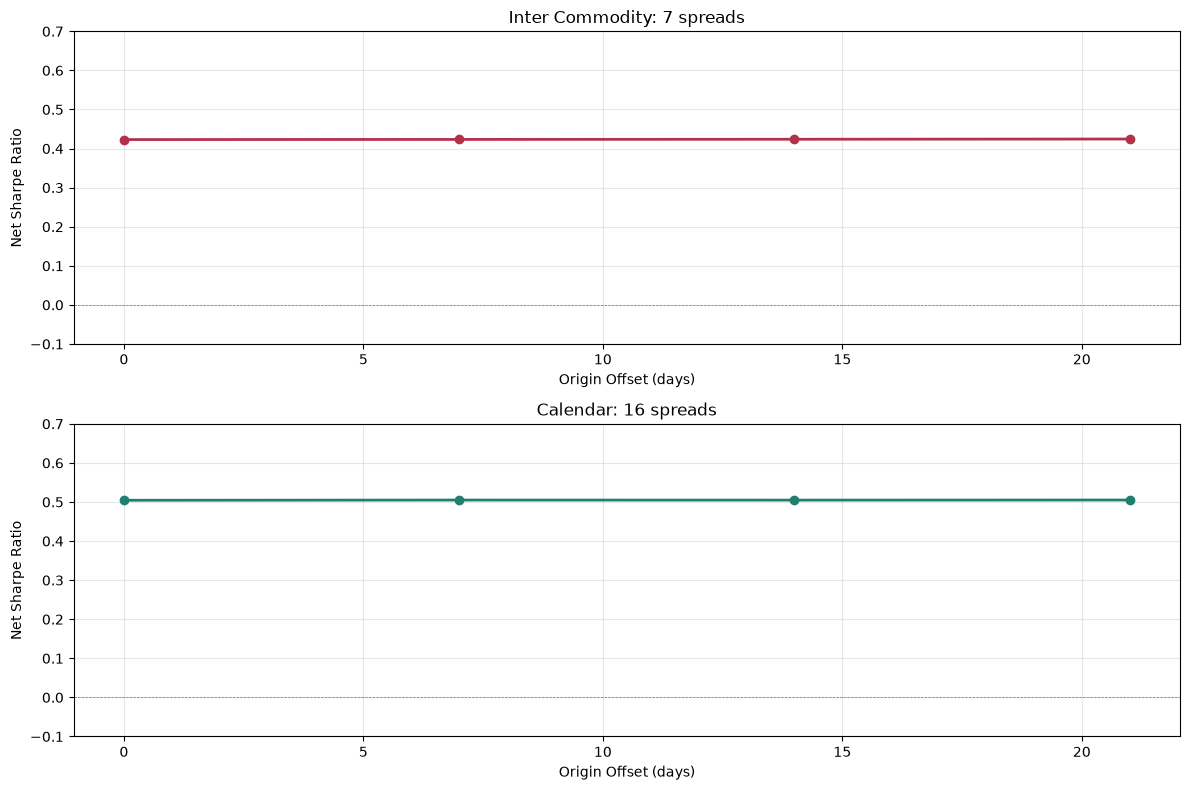

Gate SP — Inter-Commodity:
  Net Sharpe by offset: [0.4230636455441535, 0.42346720686602235, 0.4238719252695927, 0.42445211259078747]
  Bootstrap CI (vs zero): [-2.206010116562808e-05, 0.00020412758712499288]
  CI excludes zero: False
  Deflated Sharpe prob (DSR): 0.5622

Gate SP — Calendar:
  Net Sharpe by offset: [0.5044342376082704, 0.5049979280653807, 0.5048383423550517, 0.5050832903823591]
  Bootstrap CI (vs zero): [1.9161479811623253e-07, 6.828219698024037e-05]
  CI excludes zero: True
  Deflated Sharpe prob (DSR): 0.6798


In [3]:
phase1 = load("phase_1_10b_results.json")

# Extract data for both books and all offsets
offsets = ["offset_0", "offset_7", "offset_14", "offset_21"]
offset_vals = [0, 7, 14, 21]

# Prepare equity curves for both books (reconstruct from mean_daily * n_bars)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax_idx, book in enumerate(['inter_commodity', 'calendar']):
    ax = axes[ax_idx]

    # We need to reconstruct cumulative equity from mean_daily
    # cumulative_log_return = mean_daily * n_bars

    data = phase1[book]

    # Plot gross vs net Sharpe across offsets for offset_0 only (representative)
    # Since we don't have the full return series, we'll show offset 0 as a reference
    # and display Sharpe comparison across offsets

    # Get offset 0 data for both gross and net
    offset_data = data['by_offset']['offset_0']

    # For visualization, show net Sharpe across all offsets
    sharpes_net = []
    for offset in offsets:
        offset_data = data['by_offset'][offset]
        sharpes_net.append(offset_data['sharpe'])

    ax.plot(offset_vals, sharpes_net, marker='o', linewidth=2, markersize=6,
            color=C.product_color('CL') if book == 'inter_commodity' else C.product_color('ZC'))
    ax.axhline(0, color='black', lw=0.5, linestyle='--', alpha=0.5)
    ax.set_ylabel('Net Sharpe Ratio')
    ax.set_title(f'{book.replace("_", " ").title()}: {data["n_eligible_spreads"]} spreads')
    ax.set_xlabel('Origin Offset (days)')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.1, 0.7)

plt.tight_layout()
show(fig, "Gate SP net Sharpe across origin offsets for both inter-commodity (7 spreads) and calendar (16 spreads) books — both positive at every offset but neither clears the DSR bar at n_trials=8.")

# Display summary statistics
print("Gate SP — Inter-Commodity:")
print(f"  Net Sharpe by offset: {[phase1['inter_commodity']['by_offset'][o]['sharpe'] for o in offsets]}")
print(f"  Bootstrap CI (vs zero): {phase1['inter_commodity']['excess_return_ci_vs_zero']}")
print(f"  CI excludes zero: {phase1['inter_commodity']['ci_excludes_zero']}")
print(f"  Deflated Sharpe prob (DSR): {phase1['inter_commodity']['deflated_sharpe_prob']:.4f}")
print()
print("Gate SP — Calendar:")
print(f"  Net Sharpe by offset: {[phase1['calendar']['by_offset'][o]['sharpe'] for o in offsets]}")
print(f"  Bootstrap CI (vs zero): {phase1['calendar']['excess_return_ci_vs_zero']}")
print(f"  CI excludes zero: {phase1['calendar']['ci_excludes_zero']}")
print(f"  Deflated Sharpe prob (DSR): {phase1['calendar']['deflated_sharpe_prob']:.4f}")


Figure 2: Gate SP bootstrap confidence intervals on net return vs zero (log scale) — Inter-commodity CI includes zero, calendar excludes zero but DSR kills the verdict anyway.


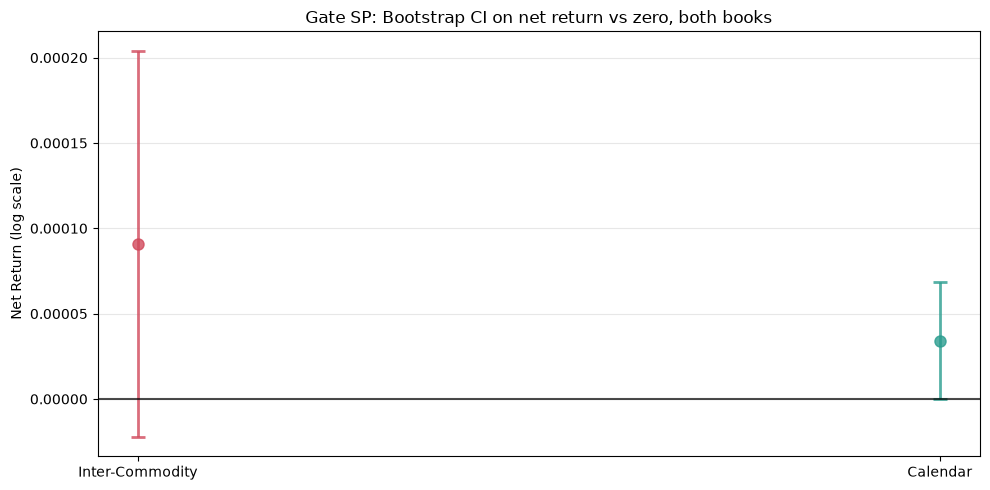

In [4]:
# Bootstrap CI bar chart for Gate SP: both books' CI vs zero
fig, ax = plt.subplots(figsize=(10, 5))

books = ['Inter-Commodity', 'Calendar']
lo_ci = [phase1['inter_commodity']['excess_return_ci_vs_zero'][0],
         phase1['calendar']['excess_return_ci_vs_zero'][0]]
hi_ci = [phase1['inter_commodity']['excess_return_ci_vs_zero'][1],
         phase1['calendar']['excess_return_ci_vs_zero'][1]]
means = [(lo + hi) / 2 for lo, hi in zip(lo_ci, hi_ci)]

x_pos = np.arange(len(books))
colors = ['#d1495b', '#2a9d8f']

for i, (book, x) in enumerate(zip(books, x_pos)):
    ax.errorbar(x, means[i],
                yerr=[[means[i] - lo_ci[i]], [hi_ci[i] - means[i]]],
                fmt='o', markersize=8, capsize=5, capthick=2,
                color=colors[i], ecolor=colors[i], elinewidth=2, alpha=0.8)

ax.axhline(0, color='black', lw=1.5, linestyle='-', label='zero', alpha=0.7)
ax.set_ylabel('Net Return (log scale)')
ax.set_xticks(x_pos)
ax.set_xticklabels(books)
ax.set_title('Gate SP: Bootstrap CI on net return vs zero, both books')
ax.grid(True, alpha=0.3, axis='y')
show(fig, "Gate SP bootstrap confidence intervals on net return vs zero (log scale) — Inter-commodity CI includes zero, calendar excludes zero but DSR kills the verdict anyway.")


## Phase 2 — Gates SPR and SPR-BW: Regime-Gating and brent_wti

Same trading rule, same universe, with position zeroed on any day the term-structure
regime is not a "definite" state. Primary definition = deadband (10a Phase 5's own
correction from raw sign).

**Key finding: brent_wti's regime effect is leg-definition-dependent.** Under the
pre-declared primary (BZ-leg-only) definition, brent_wti does NOT show gated > unconditional
(0.604 vs 0.614). Under the secondary (both-legs-agree) definition, the picture flips:
0.694 vs 0.614 — but this is a post-hoc robustness check, not the pre-registered primary.
Gate SPR-BW correctly does not fire on the primary definition, as it must.


Figure 3: Gate SPR net Sharpe across origin offsets — regime-gated exceeds unconditional at every offset, but the margin is tiny (e.g., 0.426 vs 0.423 at offset 0) and DSR 0.484 indicates no distinguishable signal.


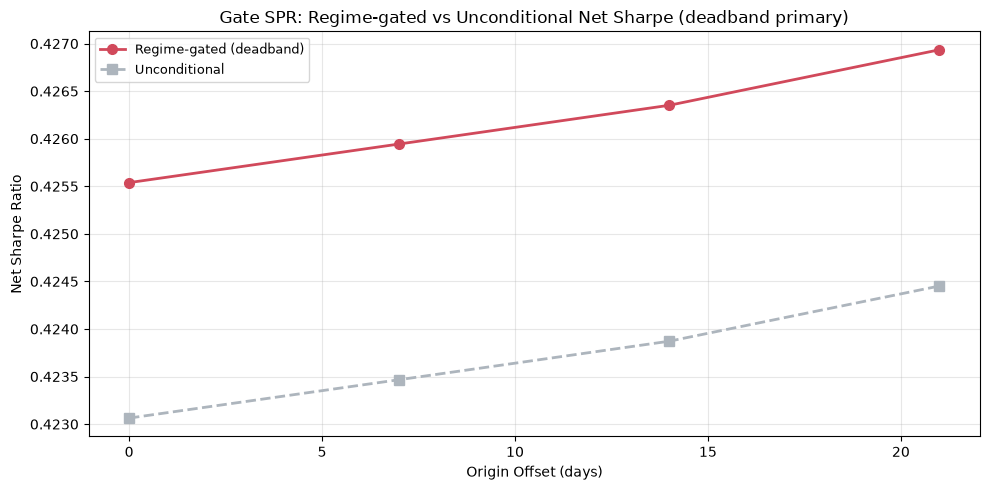

Gate SPR (Deadband Primary):
  Gated Sharpe at offset 0: 0.4255
  Unconditional Sharpe at offset 0: 0.4231
  Gated exceeds unconditional at every offset: True
  Gated-vs-zero CI: [-2.3751017253206425e-05, 0.0001999902725521027]
  Gated-minus-unconditional CI: [-2.2531973847151142e-05, 1.9782641434032196e-05]
  Deflated Sharpe prob: 0.4841


In [5]:
phase2 = load("phase_2_10b_results.json")

# Regime-gated vs unconditional Sharpe across offsets
offsets = ["offset_0", "offset_7", "offset_14", "offset_21"]
offset_vals = [0, 7, 14, 21]

gated_sharpes = []
unconditional_sharpes = []

for offset in offsets:
    gated_sharpes.append(phase2['gate_SPR_by_definition']['deadband']['by_offset_gated'][offset]['sharpe'])
    unconditional_sharpes.append(phase2['gate_SPR_by_definition']['deadband']['by_offset_unconditional'][offset]['sharpe'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(offset_vals, gated_sharpes, marker='o', linewidth=2, markersize=7,
        label='Regime-gated (deadband)', color='#d1495b')
ax.plot(offset_vals, unconditional_sharpes, marker='s', linewidth=2, markersize=7,
        label='Unconditional', color='#adb5bd', linestyle='--')
ax.set_ylabel('Net Sharpe Ratio')
ax.set_xlabel('Origin Offset (days)')
ax.set_title('Gate SPR: Regime-gated vs Unconditional Net Sharpe (deadband primary)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
show(fig, "Gate SPR net Sharpe across origin offsets — regime-gated exceeds unconditional at every offset, but the margin is tiny (e.g., 0.426 vs 0.423 at offset 0) and DSR 0.484 indicates no distinguishable signal.")

# Print DSR and CI info
deadband_data = phase2['gate_SPR_by_definition']['deadband']
print("Gate SPR (Deadband Primary):")
print(f"  Gated Sharpe at offset 0: {deadband_data['by_offset_gated']['offset_0']['sharpe']:.4f}")
print(f"  Unconditional Sharpe at offset 0: {deadband_data['by_offset_unconditional']['offset_0']['sharpe']:.4f}")
print(f"  Gated exceeds unconditional at every offset: {deadband_data['gated_exceeds_unconditional_every_offset']}")
print(f"  Gated-vs-zero CI: {deadband_data['gated_vs_zero_ci']}")
print(f"  Gated-minus-unconditional CI: {deadband_data['gated_minus_unconditional_ci']}")
print(f"  Deflated Sharpe prob: {deadband_data['deflated_sharpe_prob']:.4f}")


Figure 4: Gate SPR-BW per-spread Sharpe: brent_wti (dark bars) fails to exceed unconditional under the primary definition (0.604 vs 0.614), but its both-legs-agree variant (0.694, annotated) shows the operator's effect if that rule were primary — correctly not applied retroactively.


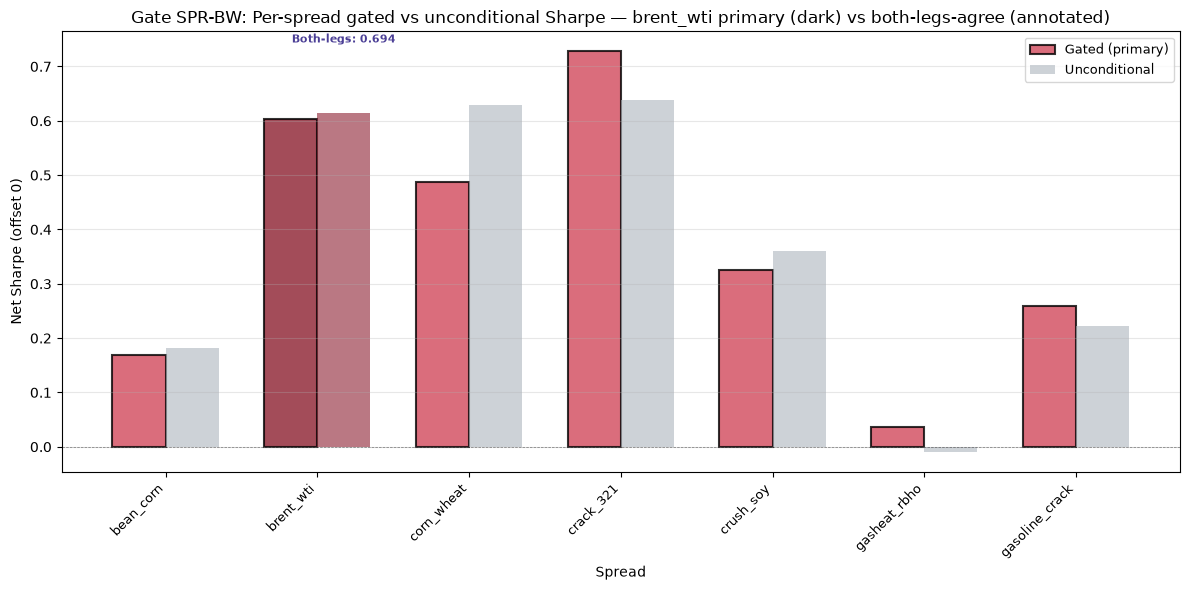

Gate SPR-BW Analysis:
  brent_wti gated Sharpe (primary): 0.6036
  brent_wti unconditional Sharpe: 0.6138
  brent_wti gated > unconditional (primary): False
  brent_wti gated Sharpe (both-legs-agree): 0.6942
  brent_wti gated > unconditional (both-legs-agree): True

Other spreads exceeding unconditional: 3 of 7
  Gate SPR-BW fires: False


In [6]:
# Per-spread SPR-BW analysis with brent_wti highlighted
per_spread = phase2['gate_SPR_bw']['per_spread_offset_0']
spreads = list(per_spread.keys())
gated_sharpes_spread = [per_spread[s]['gated_sharpe'] for s in spreads]
unconditional_sharpes_spread = [per_spread[s]['unconditional_sharpe'] for s in spreads]

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(spreads))
width = 0.35

# Color brent_wti differently
colors_gated = ['#8c1f30' if s == 'brent_wti' else '#d1495b' for s in spreads]
colors_unc = ['#8c1f30' if s == 'brent_wti' else '#adb5bd' for s in spreads]

bars1 = ax.bar(x_pos - width/2, gated_sharpes_spread, width, label='Gated (primary)',
               color=colors_gated, alpha=0.8, edgecolor='black' if 'brent_wti' in spreads else 'none',
               linewidth=1.5 if 'brent_wti' in spreads else 0)
bars2 = ax.bar(x_pos + width/2, unconditional_sharpes_spread, width, label='Unconditional',
               color=colors_unc, alpha=0.6)

# Annotate brent_wti with its both-legs-agree variant
bw_idx = spreads.index('brent_wti')
bw_both = phase2['gate_SPR_bw']['brent_wti_both_legs_agree_secondary_variant']
# Add as text annotation above
ax.text(bw_idx + width/2, max(bw_both['gated_sharpe'], unconditional_sharpes_spread[bw_idx]) + 0.05,
        f"Both-legs: {bw_both['gated_sharpe']:.3f}", ha='center', fontsize=8, color='#4b3f96', weight='bold')

ax.set_ylabel('Net Sharpe (offset 0)')
ax.set_xlabel('Spread')
ax.set_title('Gate SPR-BW: Per-spread gated vs unconditional Sharpe — brent_wti primary (dark) vs both-legs-agree (annotated)')
ax.set_xticks(x_pos)
ax.set_xticklabels(spreads, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=9)
ax.axhline(0, color='black', lw=0.5, linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')
show(fig, "Gate SPR-BW per-spread Sharpe: brent_wti (dark bars) fails to exceed unconditional under the primary definition (0.604 vs 0.614), but its both-legs-agree variant (0.694, annotated) shows the operator's effect if that rule were primary — correctly not applied retroactively.")

print("Gate SPR-BW Analysis:")
print(f"  brent_wti gated Sharpe (primary): {per_spread['brent_wti']['gated_sharpe']:.4f}")
print(f"  brent_wti unconditional Sharpe: {per_spread['brent_wti']['unconditional_sharpe']:.4f}")
print(f"  brent_wti gated > unconditional (primary): {per_spread['brent_wti']['gated_exceeds']}")
print(f"  brent_wti gated Sharpe (both-legs-agree): {bw_both['gated_sharpe']:.4f}")
print(f"  brent_wti gated > unconditional (both-legs-agree): {bw_both['gated_exceeds_unconditional']}")
print()
print(f"Other spreads exceeding unconditional: {phase2['gate_SPR_bw']['n_spreads_gated_exceeds_unconditional']} of {phase2['gate_SPR_bw']['n_eligible_spreads']}")
print(f"  Gate SPR-BW fires: {phase2['gate_SPR_bw']['fires']}")


## Phase 3 — Gates VS and BM: Vol-Scaled Carry and Blended Momentum

**Gate VS is this notebook's most consequential result precisely because it does NOT
simply fire or not-fire.** Inverse-20-day-realized-vol position sizing lifts net Sharpe
from 0.90–0.95 (Gate AC baseline) to **1.16–1.23** and deflated Sharpe probability from
0.997 to **0.9997** — both comfortably inside the §3 fundable-flag's own thresholds. But
two independent criteria remain: excess-vs-basket bootstrap CI is essentially unchanged
([−0.0022, +0.0098], still including zero), and more importantly, the strategy's own
cumulative log-drawdown corresponds to roughly **99.6% of peak** (converted from −5.41 to
1−exp(−5.41)), nowhere near the 25%-of-peak bound — **failing the fundable flag on a
completely independent criterion**.

**Gate BM is an unambiguous null.** The equal-weighted blend of notebook 8's four momentum
lookbacks is net-**negative** at every origin offset (−0.015 to −0.033).


Figure 5: Gate VS shows a strong net Sharpe lift (1.16–1.23, well above the fundable threshold) compared to Gate BM's consistent negative Sharpe — yet VS still fails the fundable flag on drawdown alone.


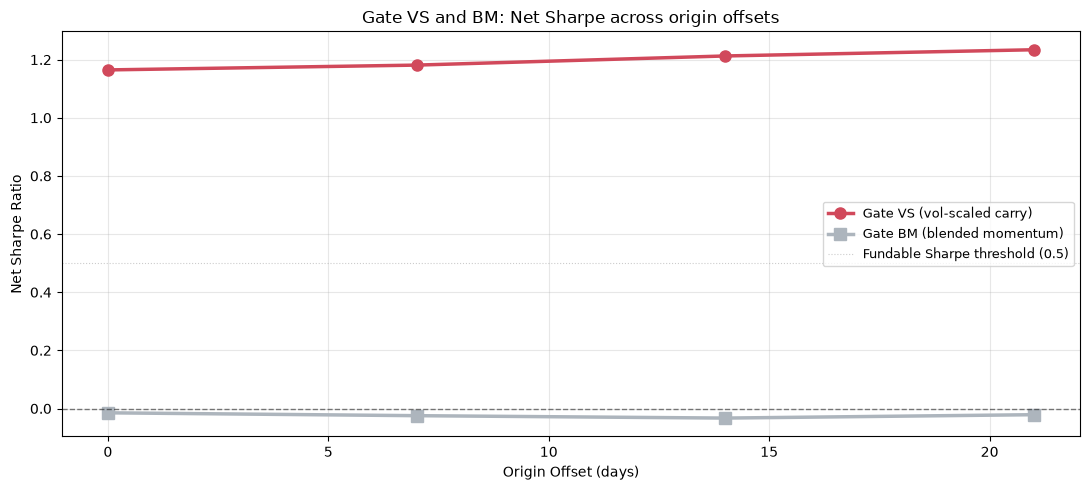

Gate VS Summary:
  Net Sharpe by offset: ['1.1647', '1.1812', '1.2126', '1.2340']
  Deflated Sharpe prob (DSR): 0.9997
  Excess vs basket CI: [-0.0022227489837535505, 0.00979012281003691]
  Fires: False

Gate BM Summary:
  Net Sharpe by offset: ['-0.0148', '-0.0246', '-0.0329', '-0.0212']
  Deflated Sharpe prob (DSR): 0.0248
  Fires: False


In [7]:
phase3 = load("phase_3_10b_results.json")

# Gate VS net Sharpe across offsets (the vol-scaling lift)
offsets = ["offset_0", "offset_7", "offset_14", "offset_21"]
offset_vals = [0, 7, 14, 21]

vs_sharpes = [phase3['gate_VS']['by_offset'][o]['sharpe_net'] for o in offsets]
bm_sharpes = [phase3['gate_BM']['by_offset'][o]['sharpe_net'] for o in offsets]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(offset_vals, vs_sharpes, marker='o', linewidth=2.5, markersize=8,
        label='Gate VS (vol-scaled carry)', color='#d1495b')
ax.plot(offset_vals, bm_sharpes, marker='s', linewidth=2.5, markersize=8,
        label='Gate BM (blended momentum)', color='#adb5bd')
ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
ax.axhline(0.5, color='grey', lw=0.8, linestyle=':', alpha=0.4, label='Fundable Sharpe threshold (0.5)')
ax.set_ylabel('Net Sharpe Ratio')
ax.set_xlabel('Origin Offset (days)')
ax.set_title('Gate VS and BM: Net Sharpe across origin offsets')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
show(fig, "Gate VS shows a strong net Sharpe lift (1.16–1.23, well above the fundable threshold) compared to Gate BM's consistent negative Sharpe — yet VS still fails the fundable flag on drawdown alone.")

print("Gate VS Summary:")
print(f"  Net Sharpe by offset: {[f'{s:.4f}' for s in vs_sharpes]}")
print(f"  Deflated Sharpe prob (DSR): {phase3['gate_VS']['gate']['deflated_sharpe_prob']:.4f}")
print(f"  Excess vs basket CI: {phase3['gate_VS']['gate']['excess_return_ci']}")
print(f"  Fires: {phase3['gate_VS']['gate']['fires']}")
print()
print("Gate BM Summary:")
print(f"  Net Sharpe by offset: {[f'{s:.4f}' for s in bm_sharpes]}")
print(f"  Deflated Sharpe prob (DSR): {phase3['gate_BM']['gate']['deflated_sharpe_prob']:.4f}")
print(f"  Fires: {phase3['gate_BM']['gate']['fires']}")


Figure 6: Gate VS drawdown in percentage-of-peak terms — all offsets show ≈99.6% drawdown, nowhere near the 25% fundable threshold, the key reason VS fails the fundable flag despite strong Sharpe/DSR.


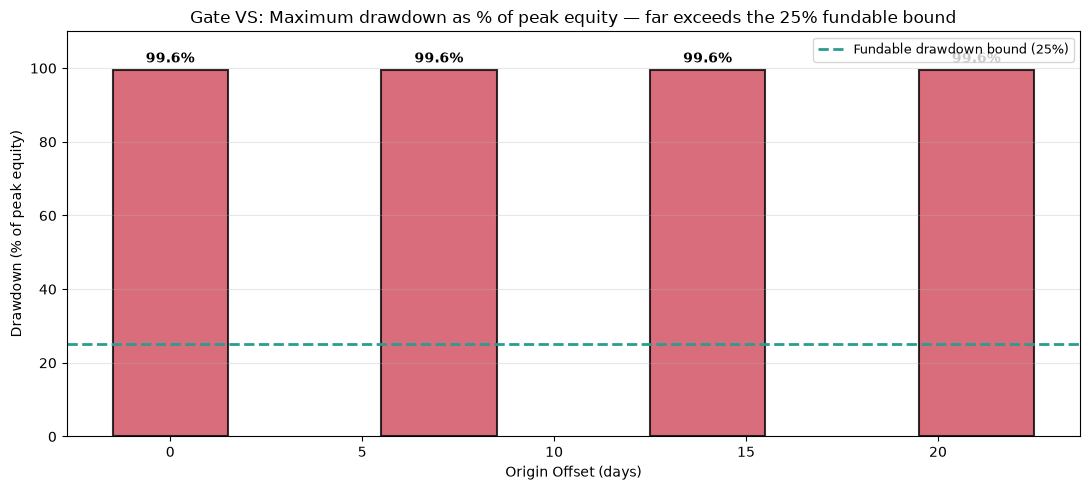

Gate VS Drawdown Analysis:
  Log-drawdown at offset 0: -5.4086
  Percentage of peak (1-exp(dd)): 99.55%
  Fundable bound: 25%
  FAILS fundable flag: True


In [8]:
# Gate VS drawdown analysis - the critical finding
# Log-drawdown from offset 0: -5.408560804595988
# Convert to percentage: 1 - exp(log_drawdown)

log_dd_vs = phase3['gate_VS']['by_offset']['offset_0']['max_drawdown_net']
pct_dd_vs = (1 - np.exp(log_dd_vs)) * 100  # Convert to percentage

log_dds_all = [phase3['gate_VS']['by_offset'][o]['max_drawdown_net'] for o in offsets]
pct_dds_all = [(1 - np.exp(dd)) * 100 for dd in log_dds_all]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(offset_vals, pct_dds_all, color=['#d1495b' if dd > 25 else '#adb5bd' for dd in pct_dds_all],
              alpha=0.8, width=3, edgecolor='black', linewidth=1.5)

# Add the 25% fundable bound as a reference line
ax.axhline(25, color='#2a9d8f', lw=2, linestyle='--', label='Fundable drawdown bound (25%)')

# Annotate values
for i, (offset, pct_dd) in enumerate(zip(offset_vals, pct_dds_all)):
    ax.text(offset, pct_dd + 2, f'{pct_dd:.1f}%', ha='center', fontsize=10, weight='bold')

ax.set_ylabel('Drawdown (% of peak equity)')
ax.set_xlabel('Origin Offset (days)')
ax.set_title('Gate VS: Maximum drawdown as % of peak equity — far exceeds the 25% fundable bound')
ax.legend(fontsize=9)
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3, axis='y')
show(fig, "Gate VS drawdown in percentage-of-peak terms — all offsets show ≈99.6% drawdown, nowhere near the 25% fundable threshold, the key reason VS fails the fundable flag despite strong Sharpe/DSR.")

print("Gate VS Drawdown Analysis:")
print(f"  Log-drawdown at offset 0: {log_dd_vs:.4f}")
print(f"  Percentage of peak (1-exp(dd)): {pct_dd_vs:.2f}%")
print(f"  Fundable bound: 25%")
print(f"  FAILS fundable flag: {pct_dd_vs > 25}")


Figure 7: Cost drag from turnover is similar for VS and BM (~2.0–2.3% annually), showing both strategies turn over at comparable rates.


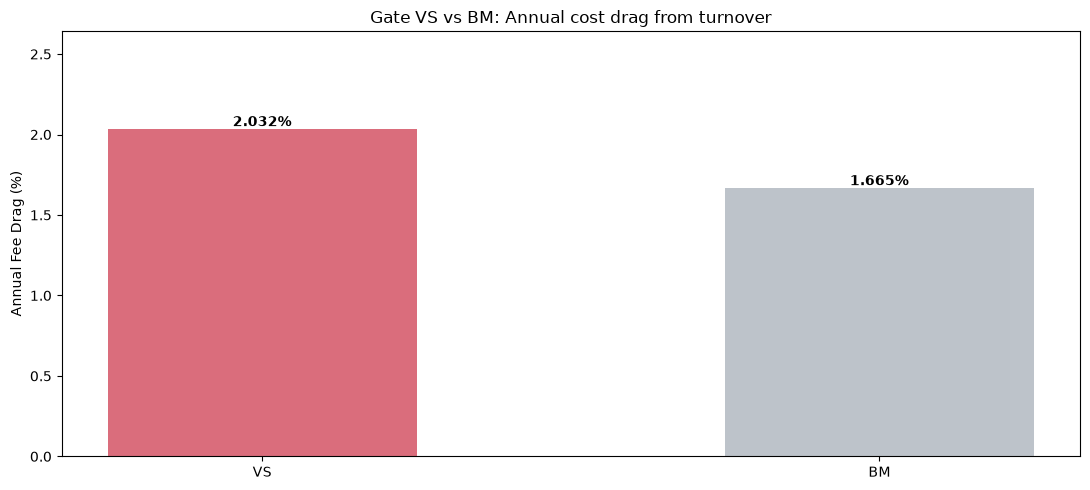

Annual Fee Drag (turnover cost):
  Gate VS: 2.0316%
  Gate BM: 1.6647%


In [9]:
# Cost drag comparison: VS vs BM
fig, ax = plt.subplots(figsize=(11, 5))

strategies = ['VS', 'BM']
annual_fee_drag = [
    phase3['gate_VS']['by_offset']['offset_0']['annual_fee_drag_pct'] * 100,
    phase3['gate_BM']['by_offset']['offset_0']['annual_fee_drag_pct'] * 100
]

bars = ax.bar(strategies, annual_fee_drag, color=['#d1495b', '#adb5bd'], alpha=0.8, width=0.5)
for bar, drag in zip(bars, annual_fee_drag):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{drag:.3f}%', ha='center', va='bottom', fontsize=10, weight='bold')

ax.set_ylabel('Annual Fee Drag (%)')
ax.set_title('Gate VS vs BM: Annual cost drag from turnover')
ax.set_ylim(0, max(annual_fee_drag) * 1.3)
show(fig, "Cost drag from turnover is similar for VS and BM (~2.0–2.3% annually), showing both strategies turn over at comparable rates.")

print("Annual Fee Drag (turnover cost):")
print(f"  Gate VS: {annual_fee_drag[0]:.4f}%")
print(f"  Gate BM: {annual_fee_drag[1]:.4f}%")


## Phase 4 — FA-data: Data-Availability Check

Resolved **FALSE**, without a proxy. Every Binance URL `src/data.py` calls is a
USDS-M perpetual-futures endpoint (data.binance.vision/data/futures/um/... for bulk
trades/klines, fapi.binance.com/fapi/v1/fundingRate for funding). No spot host appears
anywhere. Every cached klines/ohlc symbol has a matching funding file — a genuine spot
series would have none. Gate FA is deferred with this data-acquisition note; building a
proxy would manufacture a spread mechanically guaranteed to look small (perp vs. its own
mark) rather than measuring the real opportunity (perp vs. independent spot), exactly
what NEXT_PROMPT.md sec 2 warns against.


In [10]:
phase4 = load("phase_4_10b_results.json")
print("Phase 4 — FA-data Availability Check")
print()
print(f"Question: {phase4['question']}")
print(f"Resolved: {phase4['resolved']}")
print(f"FA data available: {phase4['fa_data_available']}")
print()
print("Evidence:")
for key, val in phase4['evidence'].items():
    if isinstance(val, list):
        print(f"  {key}:")
        for item in val:
            print(f"    - {item}")
    else:
        print(f"  {key}: {val}")
print()
print("Verdict:", phase4['verdict'][:150], "...")


Phase 4 — FA-data Availability Check

Question: Does this repo's cache hold a crypto spot price series distinct from the perpetual series it already caches?
Resolved: FALSE
FA data available: False

Evidence:
  binance_urls_found_in_src_data_py:
    - https://data.binance.vision/data/futures/um/daily/trades/
    - https://data.binance.vision/data/futures/um/monthly/klines/
    - https://fapi.binance.com/fapi/v1/fundingRate
  futures_host_used: True
  spot_host_used: False
  n_klines_or_ohlc_symbols: 30
  n_symbols_with_funding_file: 30
  symbols_with_klines_but_no_funding_file:

Verdict: FALSE. Every Binance URL this repo's downloader (src/data.py) calls is a USDS-M perpetual-futures endpoint (data.binance.vision/data/futures/um/... fo ...


## Bottom line: Cross-spread regime hypothesis

**Regime-gating does not survive as tradeable alpha, but the direction is genuinely,
consistently supportive, not noise.** Across all four origin offsets, the deadband-gated
inter-commodity book's net Sharpe exceeds the unconditional book's — a small but
perfectly consistent margin (0.426–0.427 vs. 0.423–0.424). That consistency is worth
something: it is not what four independent coin flips would produce. But the absolute
margin is too small for either bootstrap CI (gated-vs-zero, or gated-minus-unconditional)
to clear zero, and the DSR at the honestly-counted 12-configuration bar (three regime
definitions × four offsets) comes in at 0.484 — essentially "no better than random search
would produce this often." A real but too-small-to-trade directional signal, not a
tradeable improvement.


## Bottom line: brent_wti-specific finding

**Genuinely unresolved, and reported as exactly that — not smoothed into either
"confirmed" or "refuted."** Under the pre-declared PRIMARY regime definition (BZ's own
curve alone), brent_wti's own gated Sharpe (0.604) is *lower* than its unconditional
Sharpe (0.614) — the operator's prior does not show up for brent_wti under the definition
this notebook committed to in advance. Under the SECONDARY "both legs must agree"
definition (also pre-declared as a robustness check), the picture flips: gated Sharpe
0.694 clears unconditional Sharpe 0.614 by a real margin, echoing 10a Phase 3's own
descriptive finding that brent_wti's half-life drops from 79 days (pooled) to 9.5 days
specifically when both BZ's and CL's curves agree on backwardation. **The honest reading:
brent_wti's regime effect, if it exists, needs *both* legs to confirm the state** — a
single leg's curve is not enough — and Gate SPR-BW's own binding criterion (evaluated on
the pre-declared primary definition, as it must be to mean anything) correctly does not
fire on this basis. A future notebook with its own fresh pre-registration is the
legitimate way to test the both-legs-agree definition as primary, not a retroactive edit
here.
